# Loading and plotting validation tracks from Matthew Preistley

Workflow:

1. **Define the region** we want storms from, and a larger **tracking domain** around it.
2. **Prepare the input field**: ERA5 850 hPa relative vorticity (`vo`), 6-hourly, 0.25°.
3. **Run the Hodges tracker** (`pystormtracker.HodgesTracker`) on the whole tracking domain.
4. **Post-process** the raw tracks: keep only real, mobile, long-lived cyclones (TRACK's RSPLICE filter) that affect the region.
5. **Plot** raw vs. kept tracks.
6. **Save** the filtered tracks and a per-track summary table.
7. **Sample other ERA5 fields** (t2m, msl, 10 m wind) along the kept tracks.

Helper functions live in `stormtracker.py`.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import pystormtracker as pst

import importlib
import stormtracker as st
importlib.reload(st)  # pick up edits in stormtracker.py without restarting the kernel

<module 'stormtracker' from '/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/validation_tracks/stormtracker.py'>

## 1. Region of interest and tracking domain

Boxes are given as `(lon_min, lon_max, lat_min, lat_max)` in degrees, longitudes in −180…180.

* **`REGION`** — where we want storms: the North Atlantic storm track and Northern Europe
  (60°W–30°E, 40°N–75°N). This box is only used *after* tracking, to select tracks.
* **`DOMAIN`** — the area actually given to the tracker. It is **larger than the region** on purpose:
  * the spatial taper (`taper_points`) and the regional DCT band-pass filter distort the field near the
    domain edges, giving spurious or displaced vorticity maxima there;
  * a storm that forms west of the region (e.g. off Newfoundland) and moves in should be tracked from its
    real genesis, not from where it first crosses the box. Otherwise lifetimes, genesis positions and
    peak intensities are biased.

So we track in the big box and select tracks that affect the small box, but keep each selected track
**whole** (including the parts outside the region) so its full life cycle is available.

> With the current file the buffer is 20° to the west, 10° to the east and south, but only 5° to the
> north (the data stop at 80°N). If you download more data, a domain like `(-100, 60, 20, 90)` gives
> a more comfortable buffer.

In [11]:
#Importing the data from the file
REGION = (-80, 20, 30, 80)   # smaller region for tracking, limited by the domain, 10 deg smaller
DOMAIN = (-90, 30, 20, 90)   # tracking domain (region + buffer), limited by the downloaded data


tracks_from_matty = st.load_tracks('/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/validation_tracks/ERA5_19992000_TRACKS_FILTERED_pos.addmslp')
tracks_from_matty = tracks_from_matty.assign_coords(lon=st.wrap_lon(tracks_from_matty.lon))
summary = st.track_summary(tracks_from_matty)

long_tracks = summary.track_id[summary.n_points >= 8]
#storm7 = st.select_track(tracks_from_matty, 1)

KeyError: "No variable named 'lon'. Variables on the dataset include ['step', 'lat', 'vorticity', 'mslp_lon', 'mslp_lat', 'mslp', 'track_id']"

<GeoAxes: title={'center': 'Tracks'}>

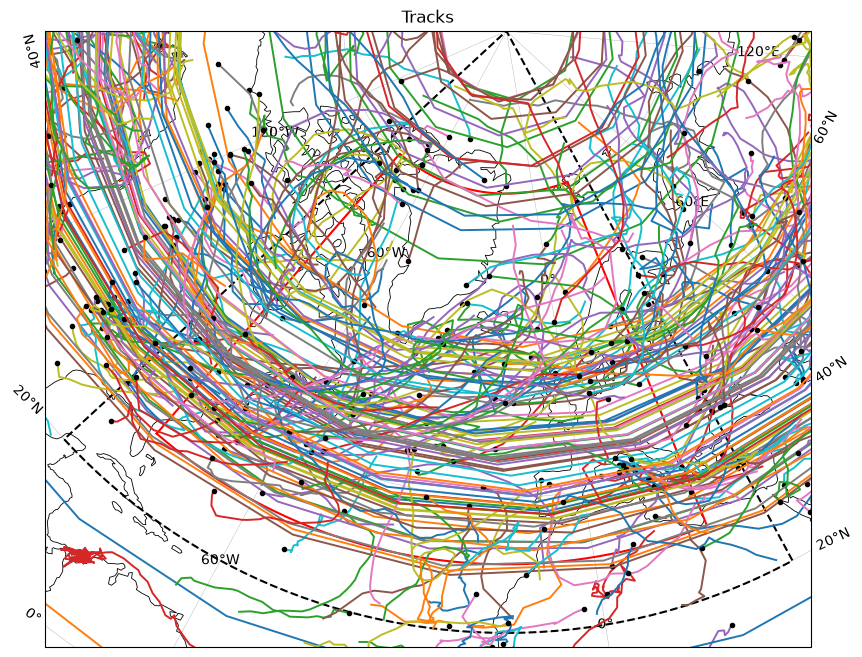

In [ ]:
st.plot_regional_tracks(tracks_from_matty, region=REGION, domain=DOMAIN, object = False)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#(west, east, south, north) 
REGION = (-80, 20, 30, 80)   # lon_min, lon_max, lat_min, lat_max
DOMAIN = (-90, 30, 20, 90)


def in_region(ds, region):
    """Boolean mask over `obs`: is the track point inside the region?"""
    lon_min, lon_max, lat_min, lat_max = region
    lon = st.wrap_lon(ds.lon)
    return (lon >= lon_min) & (lon <= lon_max) & (ds.lat >= lat_min) & (ds.lat <= lat_max)


def filter_tracks_by_region(ds, region, min_points=2):
    """Keep only tracks with at least `min_points` points inside `region`.

    Whole tracks are kept (including their points outside the region).
    """
    inside = in_region(ds, region)
    counts = inside.groupby("track_id").sum()
    keep_ids = counts.track_id.values[counts.values >= min_points]
    idx = np.where(np.isin(ds.track_id.values, keep_ids))[0]
    return ds.isel(obs=idx)


def plot_tracks(ds, region=REGION, domain=DOMAIN, ax=None, date='Dec 1999'):
    """Plot each track as a line, with the region and domain boxes."""
    if ax is None:
        fig = plt.figure(figsize=(10, 7))
        ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([domain[0]-20, domain[1]+20, domain[2]-10, domain[3]], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    lon_all = st.wrap_lon(ds.lon).values
    lat_all = ds.lat.values
    ids = ds.track_id.values
    for tid in np.unique(ids):
        m = ids == tid
        ax.plot(lon_all[m], lat_all[m], lw=1, alpha=0.8, transform=ccrs.PlateCarree())
        ax.plot(lon_all[m][0], lat_all[m][0], "o", color="C1", markersize=4, transform=ccrs.PlateCarree())

    # region box (red) and domain box (grey dashed)
    for box, style in ((region, dict(color="red", lw=1.5)),
                       (domain, dict(color="grey", lw=1, ls="--"))):
        x0, x1, y0, y1 = box
        ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0],
                transform=ccrs.PlateCarree(), **style)

    ax.set_title(f"{np.unique(ids).size} tracks in region {region} in {date}")
    return ax

### Pristleys tracks from dec 1999 - feb 2000

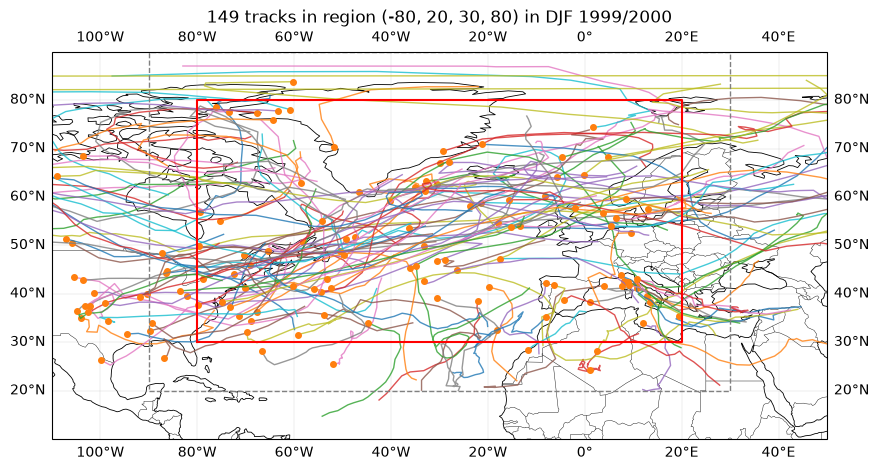

In [6]:
ds = st.load_tracks('/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/validation_tracks/ERA5_19992000_TRACKS_FILTERED_pos.addmslp')
sel = filter_tracks_by_region(ds, REGION, min_points=2)
plot_tracks(sel, date = 'DJF 1999/2000')
plt.show()


### Our tracking in dec 1999 - feb 2000

In [ ]:
our_tracks = st.hodges_tracker('/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/validation_tracks/DJF_NA_vo_1999-2000.nc')

### Algorithm for comparing tracks

Specifically we want to find whether the tracks from priestley are present in our data.  

#### Pseudo-code

for track in validation_set
    record len (start, end) +- 1 day in each end (?) in time and (lat, lon) +- (5 deg?) for start and finish

same for our set, but without +-.

If our track is in BOTH recorded metrics: yes, match

else: no match





In [ ]:
def 